1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.impute import SimpleImputer

import xgboost as xgb
import shap

2. Загрузка данных

In [2]:
df = pd.read_csv('C:/django/credit_scoring/ml_model/data/accepted_2007_to_2018Q4.csv', low_memory=False)

# print(f"Размер датасета: {df.shape}")
# print(f"Колонки: {df.columns.tolist()}")
# print(f"\nТипы данных:\n{df.dtypes.value_counts()}")

3. Создание целевой переменной

In [3]:
def create_target(status):
    if status in [
        'Charged Off', 'Default',
        'Late (31-120 days)', 'Late (16-30 days)',
        'Does not meet the credit policy. Status:Charged Off'
    ]:
        return 1
    elif status == 'Fully Paid':
        return 0
    else:
        return None

df['is_bad'] = df['loan_status'].apply(create_target)

df_model = df.dropna(subset=['is_bad']).copy()

print("Размер после фильтрации:", df_model.shape)
print("Доля дефолтов:", df_model['is_bad'].mean())

Размер после фильтрации: (1371927, 152)
Доля дефолтов: 0.21515430485732842


4. Отбор признаков

In [4]:
bank_features = [

    # 1. Платежеспособность
    'loan_amnt',
    'installment',
    'annual_inc',
    'dti',

    # 2. Кредитная дисциплина
    'delinq_2yrs',
    'acc_now_delinq',
    'pub_rec',
    'pub_rec_bankruptcies',
    'collections_12_mths_ex_med',

    # 3. Кредитная нагрузка
    'revol_util',
    'bc_util',
    'total_bal_ex_mort',
    'total_acc',
    'tot_hi_cred_lim',

    # 4. Стабильность
    'emp_length',
    'home_ownership',
    'earliest_cr_line',

    # 5. Поведенческий риск
    'inq_last_6mths',
    'mths_since_recent_inq',
    'percent_bc_gt_75'
]

available = [col for col in bank_features if col in df_model.columns]

X = df_model[available].copy()
y = df_model['is_bad'].copy()

print("Используемых признаков:", len(available))

Используемых признаков: 20


In [5]:
print("Форма X:", X.shape)
print("Типы данных:")
print(X.dtypes)

Форма X: (1371927, 20)
Типы данных:
loan_amnt                     float64
installment                   float64
annual_inc                    float64
dti                           float64
delinq_2yrs                   float64
acc_now_delinq                float64
pub_rec                       float64
pub_rec_bankruptcies          float64
collections_12_mths_ex_med    float64
revol_util                    float64
bc_util                       float64
total_bal_ex_mort             float64
total_acc                     float64
tot_hi_cred_lim               float64
emp_length                        str
home_ownership                    str
earliest_cr_line                  str
inq_last_6mths                float64
mths_since_recent_inq         float64
percent_bc_gt_75              float64
dtype: object


5. Предобработка данных

In [8]:
def preprocess(X):

    X = X.copy()

    # ==================================================
    # 1. emp_length → извлекаем число лет стажа
    # ==================================================
    X['emp_length'] = (
        X['emp_length']
        .astype(str)
        .str.extract('(\d+)')[0]   # берём только цифры
        .astype(float)
    )


    # ==================================================
    # 2. home_ownership → кодируем как числа
    # ==================================================
    X['home_ownership'] = (
        X['home_ownership']
        .astype('category')
        .cat.codes
    )


    # ==================================================
    # 3. earliest_cr_line → возраст кредитной истории
    # ==================================================
    X['earliest_cr_year'] = pd.to_datetime(
        X['earliest_cr_line'], errors='coerce'
    ).dt.year

    X['credit_history_years'] = 2018 - X['earliest_cr_year']

    X.drop(['earliest_cr_line', 'earliest_cr_year'], axis=1, inplace=True)


    # ==================================================
    # 4. revol_util и bc_util — убираем %
    # ==================================================
    for col in ['revol_util', 'bc_util', 'percent_bc_gt_75']:
        if col in X.columns:
            X[col] = (
                X[col]
                .astype(str)
                .str.replace('%','', regex=False)
            )
            X[col] = pd.to_numeric(X[col], errors='coerce')


    # ==================================================
    # 5. Финальная проверка
    # ==================================================
    print("Нечисловые столбцы после preprocess:")
    print(X.select_dtypes(include='object').columns)

    return X


# Применяем
X = preprocess(X)

print("\nТипы данных после preprocess:")
print(X.dtypes)

Нечисловые столбцы после preprocess:
Index([], dtype='str')

Типы данных после preprocess:
loan_amnt                     float64
installment                   float64
annual_inc                    float64
dti                           float64
delinq_2yrs                   float64
acc_now_delinq                float64
pub_rec                       float64
pub_rec_bankruptcies          float64
collections_12_mths_ex_med    float64
revol_util                    float64
bc_util                       float64
total_bal_ex_mort             float64
total_acc                     float64
tot_hi_cred_lim               float64
emp_length                    float64
home_ownership                   int8
inq_last_6mths                float64
mths_since_recent_inq         float64
percent_bc_gt_75              float64
credit_history_years          float64
dtype: object


6. Обработка пропущенных значений

In [9]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Пропуски после обработки:", X.isnull().sum().sum())
print("Финальное количество признаков:", X.shape[1])

Пропуски после обработки: 0
Финальное количество признаков: 20


7. Разделение на train/test

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Доля дефолтов:", y_train.mean())

Train: (1097541, 20)
Test: (274386, 20)
Доля дефолтов: 0.21515460470269449


8. Обучение XGBoost

In [11]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [300, 400],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 2, 3]
}

search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Лучший AUC:", search.best_score_)
print("Лучшие параметры:", search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучший AUC: 0.6962844605674485
Лучшие параметры: {'subsample': 0.9, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


9. Предсказания. Оценка модели на тестовых данных

In [12]:
y_pred_proba = best_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_pred_proba)
print("AUC на тесте:", auc)

AUC на тесте: 0.6954270657787387


10. Оптимизация 3-зонной модели

In [13]:
results = []

for T1 in np.arange(0.30, 0.40, 0.01):
    for T2 in np.arange(0.60, 0.70, 0.01):

        decisions = []

        for p in y_pred_proba:
            if p < T1:
                decisions.append("AUTO_APPROVE")
            elif p > T2:
                decisions.append("AUTO_REJECT")
            else:
                decisions.append("MANUAL_REVIEW")

        df_temp = pd.DataFrame({
            'PD': y_pred_proba,
            'actual': y_test,
            'decision': decisions
        })

        reject = df_temp[df_temp.decision=="AUTO_REJECT"]
        approve = df_temp[df_temp.decision=="AUTO_APPROVE"]

        precision_reject = reject['actual'].mean()
        default_approve = approve['actual'].mean()

        results.append([T1,T2,precision_reject,default_approve,
                        len(reject),len(approve)])

results_df = pd.DataFrame(results, columns=[
    'T1','T2','precision_reject',
    'default_rate_approve',
    'n_reject','n_approve'
])

results_df.sort_values(
    by=['precision_reject','default_rate_approve'],
    ascending=[False,True]
).head()

,T1,T2,precision_reject,default_rate_approve,n_reject,n_approve
9,0.30,0.69,0.466108,0.069258,24799,43923
19,0.31,0.69,0.466108,0.071900,24799,48442
29,0.32,0.69,0.466108,0.074383,24799,53063
39,0.33,0.69,0.466108,0.077460,24799,58004
49,0.34,0.69,0.466108,0.080945,24799,63154


11. Выбор лучших порогов

In [14]:
best = results_df.iloc[0]

T1 = best.T1
T2 = best.T2

print("T1:",T1,"T2:",T2)

T1: 0.3 T2: 0.6


12. Финальная 3-зонная система

In [15]:
def three_zone(pd):
    if pd < T1:
        return "AUTO_APPROVE"
    elif pd > T2:
        return "AUTO_REJECT"
    else:
        return "MANUAL_REVIEW"

decision_df = pd.DataFrame({
    'PD': y_pred_proba,
    'actual': y_test
})

decision_df['decision'] = decision_df['PD'].apply(three_zone)

decision_df.head()

,PD,actual,decision
221083,0.610684,1.0,AUTO_REJECT
1913762,0.319652,0.0,MANUAL_REVIEW
1793010,0.572718,1.0,MANUAL_REVIEW
716719,0.341033,1.0,MANUAL_REVIEW
1761226,0.325993,0.0,MANUAL_REVIEW


13. Метрики по зонам

In [16]:
approve = decision_df[decision_df.decision=="AUTO_APPROVE"]
reject = decision_df[decision_df.decision=="AUTO_REJECT"]

print("---- Автоодобрение ----")
print("Доля дефолтов:", round(approve.actual.mean(),4))
print("Количество:", len(approve))

print("\n---- Автоотказ ----")
print("Precision:", round(reject.actual.mean(),4))
print("Количество:", len(reject))

---- Автоодобрение ----
Доля дефолтов: 0.0693
Количество: 43923

---- Автоотказ ----
Precision: 0.394
Количество: 60188


14. Expected Loss

In [17]:
LGD = 0.5
EAD = 300000

decision_df['Expected_Loss'] = decision_df['PD'] * LGD * EAD

print("EL AUTO_APPROVE:",
      decision_df[decision_df.decision=="AUTO_APPROVE"]['Expected_Loss'].mean())

EL AUTO_APPROVE: 34425.543


15. SHAP

In [18]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

def explain_client(i):
    pd_val = decision_df.iloc[i]['PD']
    zone = decision_df.iloc[i]['decision']

    shap_val = shap_values[i]
    feature_names = X_test.columns

    top_idx = np.argsort(np.abs(shap_val))[::-1][:5]

    print("PD:", round(pd_val,3))
    print("Зона:", zone)
    print("\nКлючевые факторы:")

    for idx in top_idx:
        direction = "повышает риск" if shap_val[idx]>0 else "снижает риск"
        print("-", feature_names[idx], "(", direction, ")")

explain_client(0)

PD: 0.611
Зона: AUTO_REJECT

Ключевые факторы:
- dti ( повышает риск )
- mths_since_recent_inq ( повышает риск )
- loan_amnt ( снижает риск )
- tot_hi_cred_lim ( повышает риск )
- percent_bc_gt_75 ( снижает риск )


16. функция перевода PD → Score

In [19]:
PDO = 50
BaseScore = 600
BaseOdds = 1

Factor = PDO / np.log(2)
Offset = BaseScore - Factor * np.log(BaseOdds)

def pd_to_score(pd):
    pd = np.clip(pd,1e-6,1-1e-6)
    odds = (1-pd)/pd
    score = Offset + Factor*np.log(odds)
    return round(score,0)

decision_df['Score'] = decision_df['PD'].apply(pd_to_score)

decision_df.head()

,PD,actual,decision,Expected_Loss,Score
221083,0.610684,1.0,AUTO_REJECT,91602.562500,568.0
1913762,0.319652,0.0,MANUAL_REVIEW,47947.843750,654.0
1793010,0.572718,1.0,MANUAL_REVIEW,85907.656250,579.0
716719,0.341033,1.0,MANUAL_REVIEW,51155.003906,648.0
1761226,0.325993,0.0,MANUAL_REVIEW,48898.937500,652.0


17. Перевод порогов в баллы

In [20]:
score_T1 = pd_to_score(T1)
score_T2 = pd_to_score(T2)

print("PD порог автоодобрения:", T1)
print("Score порог автоодобрения:", score_T1)

print("PD порог автоотказа:", T2)
print("Score порог автоотказа:", score_T2)

PD порог автоодобрения: 0.3
Score порог автоодобрения: 661.0
PD порог автоотказа: 0.6
Score порог автоотказа: 571.0


18. Визуализация трёхзонной системы

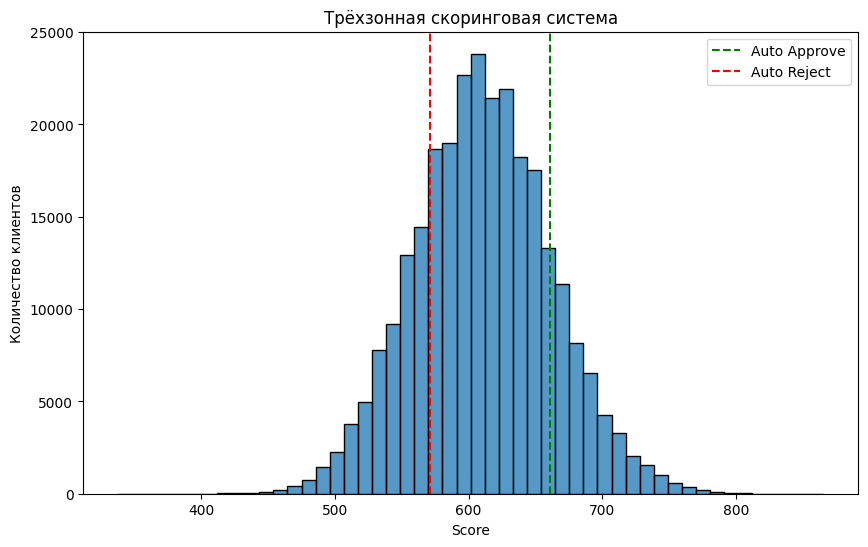

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(decision_df['Score'], bins=50)

plt.axvline(score_T1, color='green', linestyle='--', label='Auto Approve')
plt.axvline(score_T2, color='red', linestyle='--', label='Auto Reject')

plt.title("Трёхзонная скоринговая система")
plt.xlabel("Score")
plt.ylabel("Количество клиентов")
plt.legend()
plt.show()

19. Финальная проверка модели

In [22]:
# перевод зон в бинарный формат для оценки риска
decision_df['final_binary'] = decision_df['decision'].map({
    "AUTO_APPROVE": 0,
    "AUTO_REJECT": 1,
    "MANUAL_REVIEW": np.nan
})

final_eval = decision_df.dropna(subset=['final_binary'])

print(classification_report(
    final_eval['actual'],
    final_eval['final_binary']
))

              precision    recall  f1-score   support

         0.0       0.93      0.53      0.67     77355
         1.0       0.39      0.89      0.55     26756

    accuracy                           0.62    104111
   macro avg       0.66      0.71      0.61    104111
weighted avg       0.79      0.62      0.64    104111



20. Объяснение решения

In [23]:
# ==============================
# СЛОВАРЬ ПРИЧИН (банковская формулировка)
# ==============================

reason_dict = {

    'dti': 'Высокая долговая нагрузка',
    'installment': 'Размер ежемесячного платежа',
    'annual_inc': 'Низкий подтвержденный доход',
    'revol_util': 'Высокая загрузка кредитных карт',
    'tot_hi_cred_lim': 'Низкий общий кредитный лимит',
    'total_bc_limit': 'Низкий лимит по банковским картам',
    'total_bal_ex_mort': 'Высокая текущая задолженность',
    'delinq_2yrs': 'Наличие просрочек за последние 2 года',
    'pub_rec_bankruptcies': 'Факт банкротства в кредитной истории',
    'inq_last_6mths': 'Большое количество недавних запросов в БКИ',
    'mths_since_recent_inq': 'Недавние запросы на кредит',
    'credit_history_years': 'Недостаточная длительность кредитной истории',
    'emp_length': 'Короткий стаж работы',
    'open_acc': 'Большое количество открытых счетов',
    'mort_acc': 'Наличие ипотечных обязательств'
}


# ==============================
# ФУНКЦИЯ ОБЪЯСНЕНИЯ
# ==============================

def explain_full_client(i):

    pd_val = decision_df.iloc[i]['PD']
    score_val = decision_df.iloc[i]['Score']
    zone = decision_df.iloc[i]['decision']

    shap_val = shap_values[i]
    feature_names = X_test.columns

    top_idx = np.argsort(np.abs(shap_val))[::-1][:5]

    print("========== РЕШЕНИЕ ПО КЛИЕНТУ ==========")
    print("PD:", round(pd_val,3))
    print("Score:", score_val)
    print("Зона:", zone)
    print("\nКлючевые причины решения:")

    for idx in top_idx:
        feature = feature_names[idx]
        direction = "повышает риск" if shap_val[idx] > 0 else "снижает риск"

        reason_text = reason_dict.get(feature, feature)

        print(f"- {reason_text} ({direction})")

In [29]:
high_risk_index = decision_df[
    decision_df['decision'] == "AUTO_REJECT"
].iloc[0].name

explain_full_client(high_risk_index)

========== РЕШЕНИЕ ПО КЛИЕНТУ ==========
PD: 0.196
Score: 702.0
Зона: AUTO_APPROVE

Ключевые причины решения:
- Низкий общий кредитный лимит (снижает риск)
- Недостаточная длительность кредитной истории (снижает риск)
- Недавние запросы на кредит (снижает риск)
- Низкий подтвержденный доход (снижает риск)
- loan_amnt (повышает риск)


21. Сохранение модели

In [30]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/xgb_model_final.pkl")
joblib.dump(imputer, "models/imputer.pkl")

with open("models/score_params.pkl", "wb") as f:
    joblib.dump({
        "T1": T1,
        "T2": T2,
        "score_T1": score_T1,
        "score_T2": score_T2,
        "Factor": Factor,
        "Offset": Offset
    }, f)

print("Модель и параметры сохранены.")

Модель и параметры сохранены.


In [55]:
explain_full_client(0)

========== РЕШЕНИЕ ПО КЛИЕНТУ ==========
PD: 0.615
Score: 566.0
Зона: MANUAL_REVIEW

Ключевые причины решения:
- Высокая долговая нагрузка (повышает риск)
- Размер ежемесячного платежа (снижает риск)
- Недавние запросы на кредит (повышает риск)
- Низкий общий кредитный лимит (повышает риск)
- Недостаточная длительность кредитной истории (повышает риск)
